In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\pc\Downloads\datasets\IMDB Dataset.csv")

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
# Checking how many positive and negative reviews exist

df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [8]:
# Converting sentiment labels into numerical values positive reviews become 1 and negative reviews become 0

df['label'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})


df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [11]:
df['cleaned_text'] = df['review'].apply(clean_text)
df[['review','cleaned_text']].head()

,review,cleaned_text
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [12]:
X = df['cleaned_text']
y = df['label']

In [14]:
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)
X_tfidf.shape

(50000, 5000)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)


In [16]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 5000)
Testing data: (10000, 5000)


In [17]:
model = LogisticRegression(max_iter=1000)


In [18]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8928


In [21]:

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8947988223748773


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.89      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



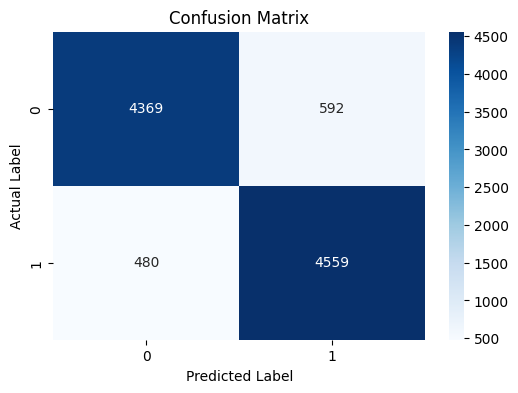

In [23]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)


# Visualizing confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [25]:

new_reviews = [
    "This was the best movie I have ever watched",
    "what a boring movie, such a waste of time it was ",
    "it was a nice movie and actors done perrrfect job"
]


# Cleaning new reviews using the same cleaning function

cleaned_reviews = [
    clean_text(review) 
    for review in new_reviews
]
review_vectors = vectorizer.transform(cleaned_reviews)
predictions = model.predict(review_vectors)


# Display results

for review, prediction in zip(new_reviews, predictions):
    
    sentiment = "Positive" if prediction == 1 else "Negative"
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
   

Review: This was the best movie I have ever watched
Predicted Sentiment: Positive
Review: what a boring movie, such a waste of time it was 
Predicted Sentiment: Negative
Review: it was a nice movie and actors done perrrfect job
Predicted Sentiment: Positive
